# Importing Libraries and Datasets

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_1 = pd.read_csv("../datasets/Audible_Catlog.csv")
df_1.drop_duplicates(inplace=True)

In [3]:
df_2 = pd.read_csv("../datasets/Audible_Catlog_Advanced_Features.csv")
df_2.drop_duplicates(inplace=True)

### Merging datasets together

In [4]:
df_merged = df_1.merge(df_2, on='Book Name', how='outer')
df_merged.drop_duplicates('Book Name', inplace=True)

In [5]:
# Reset Index
df_merged.reset_index(inplace=True)
df_merged.drop(columns=['index'], inplace=True)

# Data Preprocessing

## Data Cleaning

In [6]:
# Basic Info
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6054 entries, 0 to 6053
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Book Name            6054 non-null   object 
 1   Author_x             5396 non-null   object 
 2   Rating_x             5396 non-null   float64
 3   Number of Reviews_x  4874 non-null   float64
 4   Price_x              5394 non-null   float64
 5   Author_y             4007 non-null   object 
 6   Rating_y             4007 non-null   float64
 7   Number of Reviews_y  3630 non-null   float64
 8   Price_y              4007 non-null   float64
 9   Description          4001 non-null   object 
 10  Listening Time       4007 non-null   object 
 11  Ranks and Genre      4007 non-null   object 
dtypes: float64(6), object(6)
memory usage: 567.7+ KB


In [7]:
df_merged.describe(include='all')

,Book Name,Author_x,Rating_x,Number of Reviews_x,Price_x,Author_y,Rating_y,Number of Reviews_y,Price_y,Description,Listening Time,Ranks and Genre
count,6054,5396,5396.000000,4874.000000,5394.000000,4007,4007.000000,3630.000000,4007.000000,4001,4007,4007
unique,6054,3537,NaN,NaN,NaN,2693,NaN,NaN,NaN,2320,1021,2026
top,"""Don't You Know Who I Am?"": How to Stay Sane i...",Harvard Business Review,NaN,NaN,NaN,Harvard Business Review,NaN,NaN,NaN,"Sorry, we just need to make sure you're not a ...",-1,-1
freq,1,32,NaN,NaN,NaN,24,NaN,NaN,NaN,962,1964,1964
mean,NaN,NaN,3.928002,966.802011,931.211531,NaN,3.941527,1078.129201,960.063888,NaN,NaN,NaN
std,NaN,NaN,1.647055,2612.621093,1575.939982,NaN,1.627711,2888.341932,1673.806853,NaN,NaN,NaN
min,NaN,NaN,-1.000000,1.000000,0.000000,NaN,-1.000000,1.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,4.200000,67.000000,501.000000,NaN,4.200000,72.250000,501.000000,NaN,NaN,NaN
50%,NaN,NaN,4.500000,242.000000,683.000000,NaN,4.500000,267.500000,683.000000,NaN,NaN,NaN
75%,NaN,NaN,4.600000,798.000000,888.000000,NaN,4.600000,909.000000,888.000000,NaN,NaN,NaN


### Percentage of missing values

In [8]:
def per_miss_val(df):
  return 100 * df.isnull().sum() / len(df)

per_miss_val(df_merged)

Book Name               0.000000
Author_x               10.868847
Rating_x               10.868847
Number of Reviews_x    19.491245
Price_x                10.901883
Author_y               33.812355
Rating_y               33.812355
Number of Reviews_y    40.039643
Price_y                33.812355
Description            33.911463
Listening Time         33.812355
Ranks and Genre        33.812355
dtype: float64

### Filling missing values with existing values

In [9]:
# Author Names
df_merged['Author_x'] = df_merged['Author_x'].fillna(df_merged['Author_y'])

In [10]:
# Ratings
df_merged['Rating_x'] = df_merged['Rating_x'].fillna(df_merged['Rating_y'])

In [11]:
# No. of Reviews
df_merged['Number of Reviews_x'] = df_merged['Number of Reviews_x'].fillna(df_merged['Number of Reviews_y'])

In [12]:
# Price
df_merged['Price_x'] = df_merged['Price_x'].fillna(df_merged['Price_y'])

### Removing duplicate records

In [13]:
df_merged.drop(columns=['Author_y', 'Rating_y', 'Number of Reviews_y', 'Price_y'], inplace=True)

In [14]:
per_miss_val(df_merged)

Book Name               0.000000
Author_x                0.000000
Rating_x                0.000000
Number of Reviews_x     9.580443
Price_x                 0.016518
Description            33.911463
Listening Time         33.812355
Ranks and Genre        33.812355
dtype: float64

### Dropping rows with missing values

In [15]:
df_merged.dropna(subset=['Number of Reviews_x', 'Price_x', 'Description', 'Listening Time', 'Ranks and Genre'], inplace=True)

In [16]:
# Missing value percentage
per_miss_val(df_merged)

Book Name              0.0
Author_x               0.0
Rating_x               0.0
Number of Reviews_x    0.0
Price_x                0.0
Description            0.0
Listening Time         0.0
Ranks and Genre        0.0
dtype: float64

### Checking for Data Integrity and Consistency

In [17]:
df_merged.describe(include='all')

,Book Name,Author_x,Rating_x,Number of Reviews_x,Price_x,Description,Listening Time,Ranks and Genre
count,3625,3625,3625.000000,3625.000000,3625.000000,3625,3625,3625
unique,3625,2493,NaN,NaN,NaN,2120,972,1851
top,#Girlboss,Devdutt Pattanaik,NaN,NaN,NaN,"Sorry, we just need to make sure you're not a ...",-1,-1
freq,1,24,NaN,NaN,NaN,854,1770,1770
mean,NaN,NaN,4.453352,1070.810207,987.195034,NaN,NaN,NaN
std,NaN,NaN,0.363080,2878.321320,1742.960459,NaN,NaN,NaN
min,NaN,NaN,-1.000000,1.000000,0.000000,NaN,NaN,NaN
25%,NaN,NaN,4.300000,71.000000,512.000000,NaN,NaN,NaN
50%,NaN,NaN,4.500000,265.000000,683.000000,NaN,NaN,NaN
75%,NaN,NaN,4.700000,903.000000,888.000000,NaN,NaN,NaN


### Rating Column

Rows with `-1` represents that the book does not have any ratings. Hence removing rows with value `-1`.

In [18]:
df_merged = df_merged[df_merged['Rating_x'] != -1]

In [19]:
df_merged['Rating_x'].describe()

count    3624.000000
mean        4.454857
std         0.351643
min         1.000000
25%         4.300000
50%         4.500000
75%         4.700000
max         5.000000
Name: Rating_x, dtype: float64

### Ranks and Genre Column

Removing rows with `-1` value.

In [20]:
df_merged['Ranks and Genre'].describe()

count     3624
unique    1851
top         -1
freq      1769
Name: Ranks and Genre, dtype: object

In [21]:
df_merged = df_merged[df_merged['Ranks and Genre'] != '-1']
df_merged.reset_index(inplace=True)
df_merged.drop(columns=['index'], inplace=True)

In [22]:
df_merged['Ranks and Genre'].describe()

count                                                  1855
unique                                                 1850
top       ,            5 star,          ,            ,  ...
freq                                                      3
Name: Ranks and Genre, dtype: object

Removing rows with inconsistent/incorrect values

In [23]:
# Removing incorrent data rows
def remove_inconsistent_values(val):
    val_list = [x for x in val.split("#") if x != ',']
    for i in val_list:
        if "%" in i:
            return None
    return val_list

df_merged['Ranks and Genre'] = df_merged['Ranks and Genre'].apply(lambda x: remove_inconsistent_values(x))
df_merged.dropna(subset=['Ranks and Genre'], inplace=True)

In [24]:
def extract_ranks_and_genres(rank_list):
    audible_rank = None
    genres = []
    genre_ranks = {}
    main_genre = None
    best_rank = float('inf')

    for item in rank_list:
        if not isinstance(item, str):
            continue
        
        item = item.strip().rstrip(',')

        # Rank can follow "in" or "on"
        rank_match = re.search(r'([\d,]+)\s+(?:in|on)', item)

        # Genre ONLY after "in"
        genre_match = re.search(r'in\s+(.*)', item)

        if rank_match and genre_match:
            rank = int(rank_match.group(1).replace(',', ''))
            genre = genre_match.group(1)

            # 🔹 Clean genre (remove brackets)
            genre = re.sub(r'\(.*?\)', '', genre).strip()

            # 🔹 NEW: Remove "Audiobooks on" prefix
            if isinstance(genre, str):
                genre = re.sub(r'^Audiobooks on\s+', '', genre).strip()

            # Identify Audible rank
            if genre == "Audible Audiobooks & Originals":
                audible_rank = rank
            else:
                genres.append(genre)
                genre_ranks[genre] = rank

                # Track main genre (lowest rank = best)
                if rank < best_rank:
                    best_rank = rank
                    main_genre = genre

    return audible_rank, main_genre, genres, genre_ranks

df_merged['Audible_Rank'] = df_merged['Ranks and Genre'].apply(lambda x: extract_ranks_and_genres(x)[0])
df_merged['Main_Genre'] = df_merged['Ranks and Genre'].apply(lambda x: extract_ranks_and_genres(x)[1])
df_merged['Genre_List'] = df_merged['Ranks and Genre'].apply(lambda x: extract_ranks_and_genres(x)[2])
df_merged

,Book Name,Author_x,Rating_x,Number of Reviews_x,Price_x,Description,Listening Time,Ranks and Genre,Audible_Rank,Main_Genre,Genre_List
0,10 Essential Success Mantras from the Bhagavad...,Vimla Patil,4.2,45.0,233.0,"For thousands of years, the Bhagavad Gita has ...",26 minutes,"[3,076 in Audible Audiobooks & Originals (See ...",3076.0,Hinduism,"[Hinduism, Forecasting & Strategic Planning, L..."
1,10 Masterpieces You Have to Read Before You Die 1,Jane Austen,4.4,331.0,401.0,This Audiobook contains the following works :,102 hours and 19 minutes,"[1,485 in Audible Audiobooks & Originals (See ...",1485.0,Caribbean & Latin American Literature,"[Caribbean & Latin American Literature, Englis..."
2,10 Minutes 38 Seconds in This Strange World,Elif Shafak,4.5,507.0,752.0,Shortlisted for the Booker Prize 2019,9 hours and 11 minutes,[221 in Audible Audiobooks & Originals (See To...,221.0,Friendship Fiction,"[Friendship Fiction, Women's Fiction, Politica..."
3,100 Baggers: Stocks That Return 100-to-1 and H...,Christopher W. Mayer,4.5,178.0,668.0,This book is about 100-baggers. These are stoc...,6 hours and 19 minutes,"[2,004 in Audible Audiobooks & Originals (See ...",2004.0,Money & Finance,"[Money & Finance, Business & Economics]"
4,1000+ Little Things Happy Successful People Do...,Marc Chernoff,4.7,210.0,1005.0,New York Times best-selling authors Marc and A...,8 hours and 50 minutes,[719 in Audible Audiobooks & Originals (See To...,719.0,Personal Success,"[Personal Success, Personal Development & Self..."
...,...,...,...,...,...,...,...,...,...,...,...
1850,"Zero Day: John Puller, Book 1",David Baldacci,4.4,4921.0,323.0,John Puller is a former war hero and now the b...,13 hours and 7 minutes,"[1,971 in Audible Audiobooks & Originals (See ...",1971.0,International Mystery & Crime,"[International Mystery & Crime, War & Military..."
1851,Zero Limits: The Secret Hawaiian System for We...,Joe Vitale,4.4,886.0,703.0,If it seems like you work hard but never get ...,6 hours and 21 minutes,"[1,387 in Audible Audiobooks & Originals (See ...",1387.0,Small Businesses,"[Small Businesses, Business Motivation & Self-..."
1852,Zero to One,Peter Thiel,4.4,5306.0,615.0,What valuable company is nobody building? The ...,4 hours and 50 minutes,[25 in Audible Audiobooks & Originals (See Top...,25.0,Business Management,"[Business Management, Entrepreneurship, Organi..."
1853,Zindagi Aais Pais,Nikhil Sachan,4.1,198.0,501.0,"Zindagi Aais Pais, a short story collection, i...",4 hours and 4 minutes,"[3,026 in Audible Audiobooks & Originals (See ...",3026.0,Fiction Short Stories,"[Fiction Short Stories, Short Stories]"


In [25]:
per_miss_val(df_merged)

Book Name              0.000000
Author_x               0.000000
Rating_x               0.000000
Number of Reviews_x    0.000000
Price_x                0.000000
Description            0.000000
Listening Time         0.000000
Ranks and Genre        0.000000
Audible_Rank           3.869210
Main_Genre             0.108992
Genre_List             0.000000
dtype: float64

Filling missing values in `Audible_Rank` with `-1`

In [26]:
df_merged['Audible_Rank'] = df_merged['Audible_Rank'].fillna(-1)

In [27]:
per_miss_val(df_merged)

Book Name              0.000000
Author_x               0.000000
Rating_x               0.000000
Number of Reviews_x    0.000000
Price_x                0.000000
Description            0.000000
Listening Time         0.000000
Ranks and Genre        0.000000
Audible_Rank           0.000000
Main_Genre             0.108992
Genre_List             0.000000
dtype: float64

In [28]:
df_merged.dropna(subset=['Main_Genre'], inplace=True)

In [29]:
per_miss_val(df_merged)

Book Name              0.0
Author_x               0.0
Rating_x               0.0
Number of Reviews_x    0.0
Price_x                0.0
Description            0.0
Listening Time         0.0
Ranks and Genre        0.0
Audible_Rank           0.0
Main_Genre             0.0
Genre_List             0.0
dtype: float64

### Renaming and Re-Arranging columns

In [30]:
df_merged.rename(columns={
    'Book Name':'Book_Name',
    'Author_x':'Author',
    'Rating_x':'Rating',
    'Number of Reviews_x':'Number_of_Reviews',
    'Price_x':'Price',
    'Listening Time':'Listening_Time'
    },
    inplace=True
)

df_filled = df_merged.copy()
df_filled = df_filled[['Book_Name','Author','Rating','Number_of_Reviews','Price','Description','Listening_Time','Audible_Rank','Main_Genre', 'Genre_List']]
df_filled

,Book_Name,Author,Rating,Number_of_Reviews,Price,Description,Listening_Time,Audible_Rank,Main_Genre,Genre_List
0,10 Essential Success Mantras from the Bhagavad...,Vimla Patil,4.2,45.0,233.0,"For thousands of years, the Bhagavad Gita has ...",26 minutes,3076.0,Hinduism,"[Hinduism, Forecasting & Strategic Planning, L..."
1,10 Masterpieces You Have to Read Before You Die 1,Jane Austen,4.4,331.0,401.0,This Audiobook contains the following works :,102 hours and 19 minutes,1485.0,Caribbean & Latin American Literature,"[Caribbean & Latin American Literature, Englis..."
2,10 Minutes 38 Seconds in This Strange World,Elif Shafak,4.5,507.0,752.0,Shortlisted for the Booker Prize 2019,9 hours and 11 minutes,221.0,Friendship Fiction,"[Friendship Fiction, Women's Fiction, Politica..."
3,100 Baggers: Stocks That Return 100-to-1 and H...,Christopher W. Mayer,4.5,178.0,668.0,This book is about 100-baggers. These are stoc...,6 hours and 19 minutes,2004.0,Money & Finance,"[Money & Finance, Business & Economics]"
4,1000+ Little Things Happy Successful People Do...,Marc Chernoff,4.7,210.0,1005.0,New York Times best-selling authors Marc and A...,8 hours and 50 minutes,719.0,Personal Success,"[Personal Success, Personal Development & Self..."
...,...,...,...,...,...,...,...,...,...,...
1850,"Zero Day: John Puller, Book 1",David Baldacci,4.4,4921.0,323.0,John Puller is a former war hero and now the b...,13 hours and 7 minutes,1971.0,International Mystery & Crime,"[International Mystery & Crime, War & Military..."
1851,Zero Limits: The Secret Hawaiian System for We...,Joe Vitale,4.4,886.0,703.0,If it seems like you work hard but never get ...,6 hours and 21 minutes,1387.0,Small Businesses,"[Small Businesses, Business Motivation & Self-..."
1852,Zero to One,Peter Thiel,4.4,5306.0,615.0,What valuable company is nobody building? The ...,4 hours and 50 minutes,25.0,Business Management,"[Business Management, Entrepreneurship, Organi..."
1853,Zindagi Aais Pais,Nikhil Sachan,4.1,198.0,501.0,"Zindagi Aais Pais, a short story collection, i...",4 hours and 4 minutes,3026.0,Fiction Short Stories,"[Fiction Short Stories, Short Stories]"


In [31]:
# Percentage of missing values
per_miss_val(df_filled)

Book_Name            0.0
Author               0.0
Rating               0.0
Number_of_Reviews    0.0
Price                0.0
Description          0.0
Listening_Time       0.0
Audible_Rank         0.0
Main_Genre           0.0
Genre_List           0.0
dtype: float64

In [32]:
df_filled.describe(include='all')

,Book_Name,Author,Rating,Number_of_Reviews,Price,Description,Listening_Time,Audible_Rank,Main_Genre,Genre_List
count,1833,1833,1833.000000,1833.000000,1833.000000,1833,1833,1833.000000,1833,1833
unique,1833,1366,NaN,NaN,NaN,1699,966,NaN,658,1504
top,10 Essential Success Mantras from the Bhagavad...,Devdutt Pattanaik,NaN,NaN,NaN,Brought to you by Penguin.,11 hours and 4 minutes,NaN,Personal Success,"[Personal Success, Personal Development & Self..."
freq,1,19,NaN,NaN,NaN,55,9,NaN,68,43
mean,NaN,NaN,4.460720,1383.936716,1046.879978,NaN,NaN,2264.413530,NaN,NaN
std,NaN,NaN,0.339544,3569.923793,1872.615627,NaN,NaN,3109.107548,NaN,NaN
min,NaN,NaN,1.000000,1.000000,0.000000,NaN,NaN,-1.000000,NaN,NaN
25%,NaN,NaN,4.400000,92.000000,569.000000,NaN,NaN,613.000000,NaN,NaN
50%,NaN,NaN,4.500000,354.000000,703.000000,NaN,NaN,1936.000000,NaN,NaN
75%,NaN,NaN,4.600000,1154.000000,930.000000,NaN,NaN,3289.000000,NaN,NaN


## Data Formatting

In [33]:
df_filled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1833 entries, 0 to 1854
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Book_Name          1833 non-null   object 
 1   Author             1833 non-null   object 
 2   Rating             1833 non-null   float64
 3   Number_of_Reviews  1833 non-null   float64
 4   Price              1833 non-null   float64
 5   Description        1833 non-null   object 
 6   Listening_Time     1833 non-null   object 
 7   Audible_Rank       1833 non-null   float64
 8   Main_Genre         1833 non-null   object 
 9   Genre_List         1833 non-null   object 
dtypes: float64(4), object(6)
memory usage: 157.5+ KB


### Converting `Listening_Time` from object to timedelta

In [34]:
def extract_hours_minutes(text):
    hours = 0
    minutes = 0

    h = re.search(r'(\d+)\s*hour', text)
    m = re.search(r'(\d+)\s*minute', text)

    if h:
        hours = int(h.group(1))
    if m:
        minutes = int(m.group(1))
    
    return pd.Timedelta(hours=hours, minutes=minutes)

df_filled['Listening_Time'] = df_filled['Listening_Time'].apply(lambda x: extract_hours_minutes(x))

In [35]:
df_filled

,Book_Name,Author,Rating,Number_of_Reviews,Price,Description,Listening_Time,Audible_Rank,Main_Genre,Genre_List
0,10 Essential Success Mantras from the Bhagavad...,Vimla Patil,4.2,45.0,233.0,"For thousands of years, the Bhagavad Gita has ...",0 days 00:26:00,3076.0,Hinduism,"[Hinduism, Forecasting & Strategic Planning, L..."
1,10 Masterpieces You Have to Read Before You Die 1,Jane Austen,4.4,331.0,401.0,This Audiobook contains the following works :,4 days 06:19:00,1485.0,Caribbean & Latin American Literature,"[Caribbean & Latin American Literature, Englis..."
2,10 Minutes 38 Seconds in This Strange World,Elif Shafak,4.5,507.0,752.0,Shortlisted for the Booker Prize 2019,0 days 09:11:00,221.0,Friendship Fiction,"[Friendship Fiction, Women's Fiction, Politica..."
3,100 Baggers: Stocks That Return 100-to-1 and H...,Christopher W. Mayer,4.5,178.0,668.0,This book is about 100-baggers. These are stoc...,0 days 06:19:00,2004.0,Money & Finance,"[Money & Finance, Business & Economics]"
4,1000+ Little Things Happy Successful People Do...,Marc Chernoff,4.7,210.0,1005.0,New York Times best-selling authors Marc and A...,0 days 08:50:00,719.0,Personal Success,"[Personal Success, Personal Development & Self..."
...,...,...,...,...,...,...,...,...,...,...
1850,"Zero Day: John Puller, Book 1",David Baldacci,4.4,4921.0,323.0,John Puller is a former war hero and now the b...,0 days 13:07:00,1971.0,International Mystery & Crime,"[International Mystery & Crime, War & Military..."
1851,Zero Limits: The Secret Hawaiian System for We...,Joe Vitale,4.4,886.0,703.0,If it seems like you work hard but never get ...,0 days 06:21:00,1387.0,Small Businesses,"[Small Businesses, Business Motivation & Self-..."
1852,Zero to One,Peter Thiel,4.4,5306.0,615.0,What valuable company is nobody building? The ...,0 days 04:50:00,25.0,Business Management,"[Business Management, Entrepreneurship, Organi..."
1853,Zindagi Aais Pais,Nikhil Sachan,4.1,198.0,501.0,"Zindagi Aais Pais, a short story collection, i...",0 days 04:04:00,3026.0,Fiction Short Stories,"[Fiction Short Stories, Short Stories]"


### FINAL Dataframe for Exploratory Data Analysis

In [36]:
book_df = df_filled.copy()

# Exploratory Data Analysis

In [37]:
book_df.describe(include='all')

,Book_Name,Author,Rating,Number_of_Reviews,Price,Description,Listening_Time,Audible_Rank,Main_Genre,Genre_List
count,1833,1833,1833.000000,1833.000000,1833.000000,1833,1833,1833.000000,1833,1833
unique,1833,1366,NaN,NaN,NaN,1699,NaN,NaN,658,1504
top,10 Essential Success Mantras from the Bhagavad...,Devdutt Pattanaik,NaN,NaN,NaN,Brought to you by Penguin.,NaN,NaN,Personal Success,"[Personal Success, Personal Development & Self..."
freq,1,19,NaN,NaN,NaN,55,NaN,NaN,68,43
mean,NaN,NaN,4.460720,1383.936716,1046.879978,NaN,0 days 10:20:59.279869067,2264.413530,NaN,NaN
std,NaN,NaN,0.339544,3569.923793,1872.615627,NaN,0 days 09:24:45.123327018,3109.107548,NaN,NaN
min,NaN,NaN,1.000000,1.000000,0.000000,NaN,0 days 00:00:00,-1.000000,NaN,NaN
25%,NaN,NaN,4.400000,92.000000,569.000000,NaN,0 days 05:25:00,613.000000,NaN,NaN
50%,NaN,NaN,4.500000,354.000000,703.000000,NaN,0 days 08:19:00,1936.000000,NaN,NaN
75%,NaN,NaN,4.600000,1154.000000,930.000000,NaN,0 days 12:35:00,3289.000000,NaN,NaN


### 1. Most popular genres

In [45]:
popular_gernes = book_df['Main_Genre'].value_counts().reset_index(name='Count')
popular_gernes['Rank'] = popular_gernes.index + 1
popular_gernes = popular_gernes.head(10)

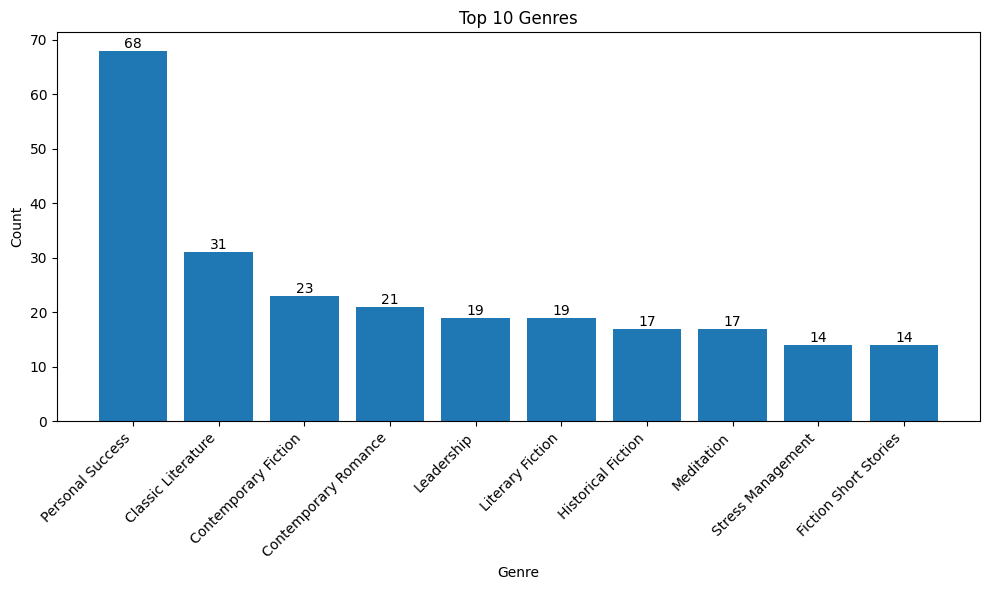

In [46]:
plt.figure(figsize=(10, 6))

plt.bar(popular_gernes['Main_Genre'], popular_gernes['Count'])

# Rotate x-axis labels
plt.xticks(rotation=45, ha='right')

# Add count labels on bars
for x, y in zip(popular_gernes['Main_Genre'], popular_gernes['Count']):
    plt.text(x, y, str(y), ha='center', va='bottom')

plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Genres')

plt.tight_layout()
plt.show()

### 2. Authors with highest-rated books

In [56]:
highest_rating = book_df['Rating'].sort_values(ascending=False)